# Pairs Trading Backtest — Kalman Filter Only
**KO / PEP** | Kalman hedge ratio + rolling z-score + fixed thresholds

No OU process. The Kalman filter gives a cleaner spread than rolling OLS,
and the z-score is computed over a fixed rolling window with fixed entry/exit thresholds.

## Cell 1 — Imports

In [2]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import download_prices, get_log_prices
from src.signals_kalman_ou import kalman_hedge_ratio, compute_kalman_spread
from src.signals_rolling import compute_rolling_zscore, generate_positions
from src.backtest import run_backtest
from src.metrics import summarize_results

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Cell 2 — Download data

In [3]:
TICKERS = ['PEP', 'KO']
START   = '2015-01-01'
END     = '2022-12-31'

prices     = download_prices(TICKERS, start=START, end=END)
log_prices = get_log_prices(prices)

print(f'Loaded {len(prices)} bars  |  {prices.index[0].date()} → {prices.index[-1].date()}')
prices.tail(3)

[*********************100%***********************]  2 of 2 completed

Loaded 2014 bars  |  2015-01-02 → 2022-12-30


Ticker,KO,PEP
Date,,
2022-12-28,57.318924,161.461044
2022-12-29,57.661564,161.665421
2022-12-30,57.355003,160.492737


## Cell 3 — Kalman hedge ratio + spread

In [17]:
# --- parameters ---
KALMAN_DELTA = 1e-4   # how fast beta drifts — increase if beta tracks too slowly
KALMAN_R     = 1e-2   # observation noise
ZSCORE_WINDOW = 60    # rolling window for z-score (bars)
ENTRY        = 1.55    # z-score entry threshold
EXIT_Z       = 0.3    # z-score exit threshold
STOP         = None   # e.g. 1.5 to add a stop-loss

# Step 1: Kalman hedge ratio
kalman_ratios = kalman_hedge_ratio(
    log_prices,
    y_col = 'PEP',
    x_col = 'KO',
    delta = KALMAN_DELTA,
    R_var = KALMAN_R,
)

# Step 2: Spread using Kalman beta
spread = compute_kalman_spread(
    log_prices,
    kalman_ratios,
    y_col = 'PEP',
    x_col = 'KO',
)

print(f'Kalman beta range: {kalman_ratios["beta"].min():.3f} → {kalman_ratios["beta"].max():.3f}')
print(f'Spread std: {spread.std():.4f}')

Kalman beta range: 0.836 → 1.150
Spread std: 0.0072


## Cell 4 — Rolling z-score + positions

In [18]:
# Step 3: Fixed rolling z-score (no OU)
zscore = compute_rolling_zscore(spread, window=ZSCORE_WINDOW)

# Step 4: Positions with fixed thresholds
positions = generate_positions(zscore, entry=ENTRY, exit=EXIT_Z)

print(f'Z-score describe:\n{zscore.dropna().describe()}\n')
print(f'Positions value counts:\n{positions.value_counts().sort_index()}')

Z-score describe:
count    1955.000000
mean       -0.005303
std         1.047659
min        -5.652698
25%        -0.588243
50%        -0.016915
75%         0.582280
max         5.992881
Name: spread, dtype: float64

Positions value counts:
position
-1     229
 0    1550
 1     235
Name: count, dtype: int64


## Cell 5 — Run backtest

In [19]:
bt = run_backtest(
    prices        = prices,
    positions     = positions,
    hedge_ratios  = kalman_ratios,
    y_col         = 'PEP',
    x_col         = 'KO',
    tc_rate       = 0.0002,
    slippage_rate = 0.0005,
)

summary = summarize_results(bt)
print('─' * 35)
for k, v in summary.items():
    print(f'  {k:<18} {v:>10.4f}')
print('─' * 35)

# Cost breakdown
total_costs = bt['trading_costs'].sum()
gross_pnl   = (bt['daily_pnl'] + bt['trading_costs']).sum()
net_pnl     = bt['daily_pnl'].sum()
cost_drag   = total_costs / abs(gross_pnl) * 100 if gross_pnl != 0 else np.nan
print(f'\n  Gross PnL        : ${gross_pnl:>10.2f}')
print(f'  Total costs      : ${total_costs:>10.2f}')
print(f'  Net PnL          : ${net_pnl:>10.2f}')
print(f'  Cost drag        : {cost_drag:>9.1f}% of gross')

───────────────────────────────────
  total_pnl             32.0959
  sharpe                 0.4435
  max_drawdown         -19.1380
  num_trades           230.0000
───────────────────────────────────

  Gross PnL        : $     55.01
  Total costs      : $     22.92
  Net PnL          : $     32.10
  Cost drag        :      41.7% of gross


## Cell 6 — Plot: Kalman beta

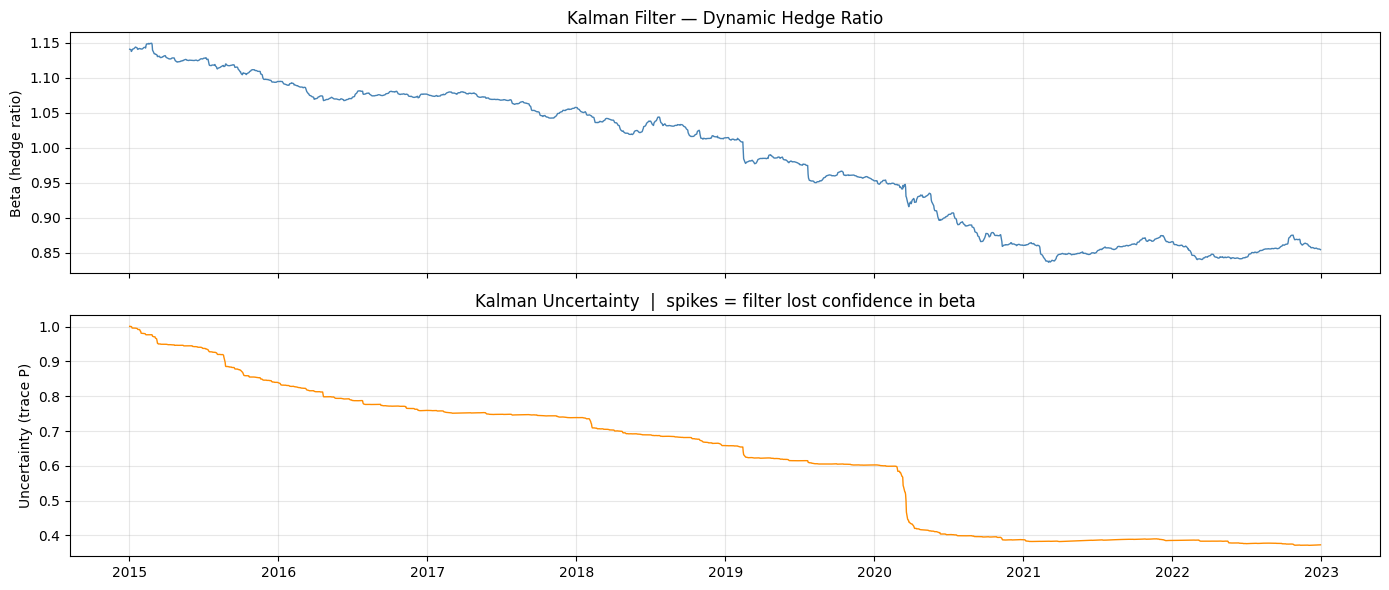

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(kalman_ratios['beta'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Beta (hedge ratio)')
axes[0].set_title('Kalman Filter — Dynamic Hedge Ratio')

axes[1].plot(kalman_ratios['uncertainty'], color='darkorange', linewidth=1)
axes[1].set_ylabel('Uncertainty (trace P)')
axes[1].set_title('Kalman Uncertainty  |  spikes = filter lost confidence in beta')

plt.tight_layout()
plt.show()

## Cell 7 — Plot: Spread

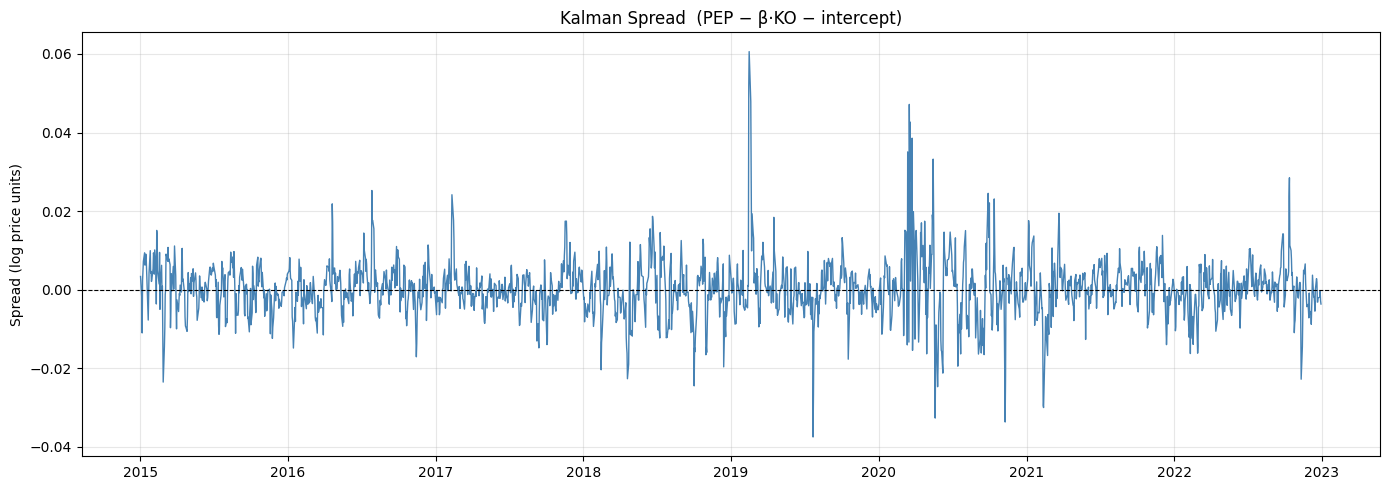

In [21]:
plt.figure()
plt.plot(spread, color='steelblue', linewidth=1)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Kalman Spread  (PEP − β·KO − intercept)')
plt.ylabel('Spread (log price units)')
plt.tight_layout()
plt.show()

## Cell 8 — Plot: Z-score with thresholds and positions

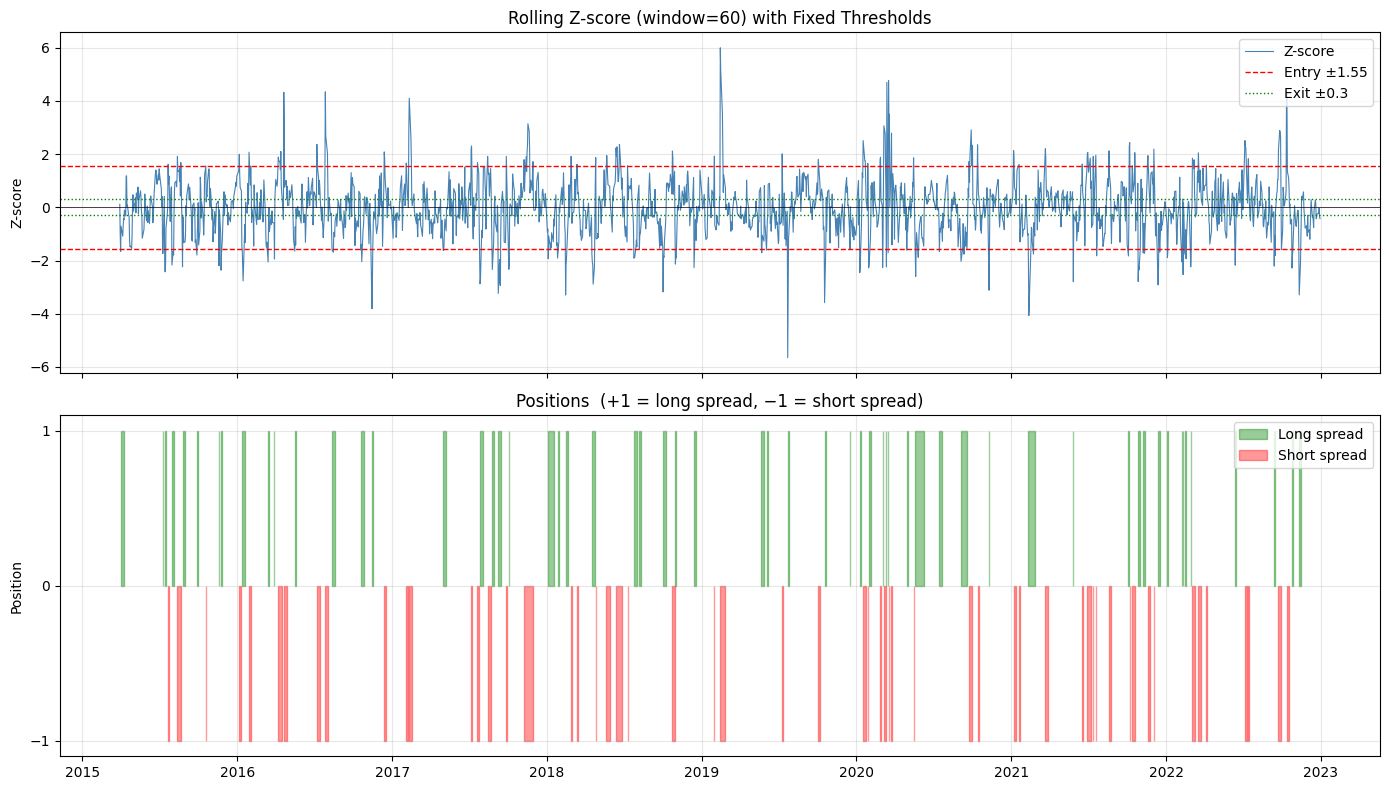

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Z-score
ax = axes[0]
ax.plot(zscore, color='steelblue', linewidth=0.8, label='Z-score')
ax.axhline( ENTRY,  color='red',   linewidth=1, linestyle='--', label=f'Entry ±{ENTRY}')
ax.axhline(-ENTRY,  color='red',   linewidth=1, linestyle='--')
ax.axhline( EXIT_Z, color='green', linewidth=1, linestyle=':',  label=f'Exit ±{EXIT_Z}')
ax.axhline(-EXIT_Z, color='green', linewidth=1, linestyle=':')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Z-score')
ax.set_title(f'Rolling Z-score (window={ZSCORE_WINDOW}) with Fixed Thresholds')
ax.legend(loc='upper right')

# Positions
ax2 = axes[1]
ax2.fill_between(positions.index, positions, 0,
                 where=positions > 0, color='green', alpha=0.4, label='Long spread')
ax2.fill_between(positions.index, positions, 0,
                 where=positions < 0, color='red',   alpha=0.4, label='Short spread')
ax2.set_ylabel('Position')
ax2.set_title('Positions  (+1 = long spread, −1 = short spread)')
ax2.set_yticks([-1, 0, 1])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Cell 9 — Plot: Cumulative PnL + drawdown

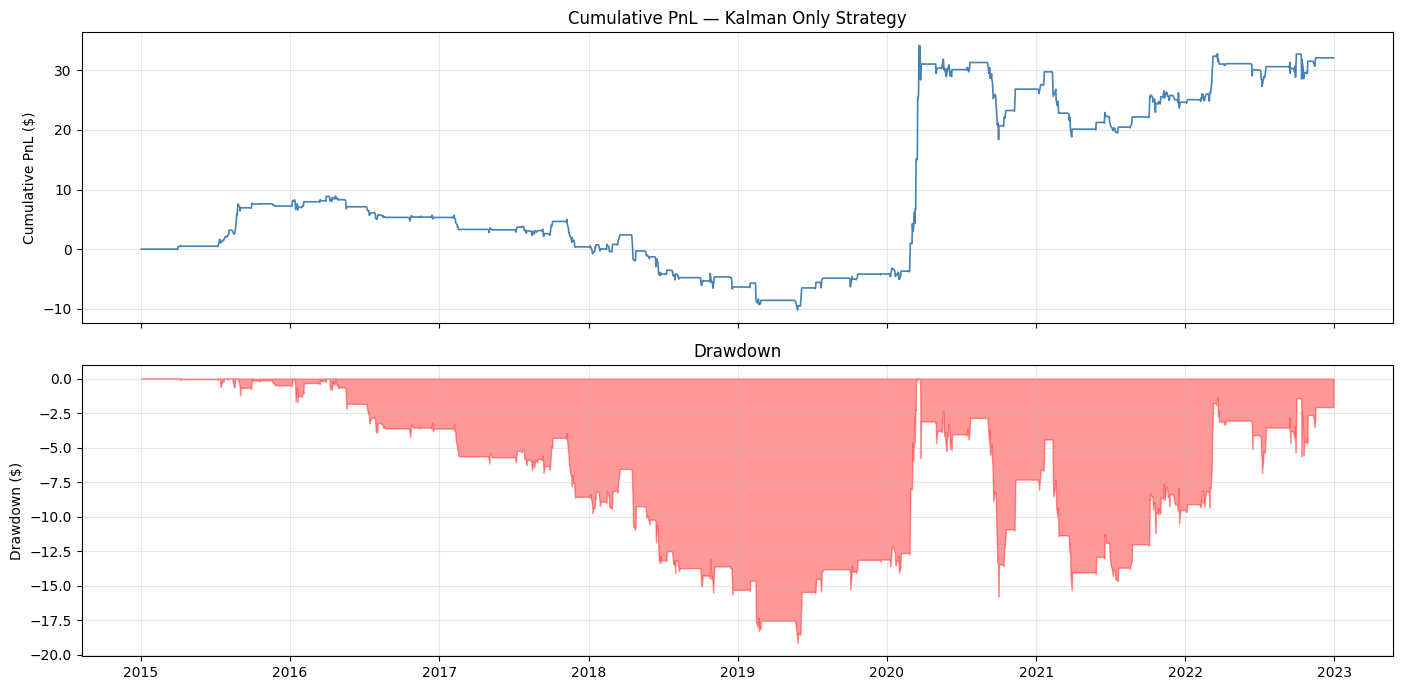

In [23]:
cum_pnl     = bt['cum_pnl']
running_max = cum_pnl.cummax()
drawdown    = cum_pnl - running_max

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(cum_pnl, color='steelblue', linewidth=1.2)
axes[0].set_ylabel('Cumulative PnL ($)')
axes[0].set_title('Cumulative PnL — Kalman Only Strategy')

axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_title('Drawdown')

plt.tight_layout()
plt.show()

## Cell 10 — Daily PnL distribution + rolling Sharpe

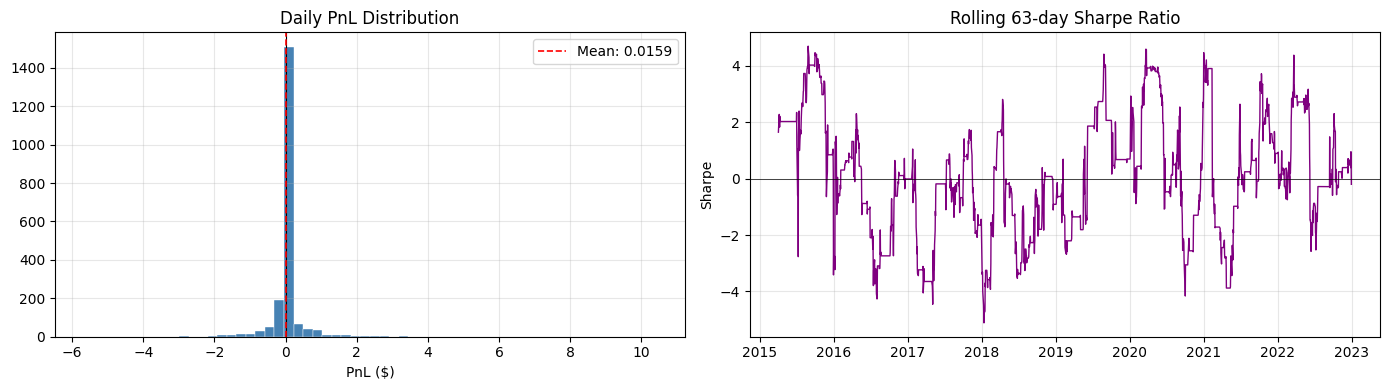

In [24]:
daily_pnl = bt['daily_pnl'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(daily_pnl, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(daily_pnl.mean(), color='red', linewidth=1.2, linestyle='--',
                label=f'Mean: {daily_pnl.mean():.4f}')
axes[0].set_title('Daily PnL Distribution')
axes[0].set_xlabel('PnL ($)')
axes[0].legend()

rolling_sharpe = daily_pnl.rolling(63).apply(
    lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan
)
axes[1].plot(rolling_sharpe, color='purple', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Rolling 63-day Sharpe Ratio')
axes[1].set_ylabel('Sharpe')

plt.tight_layout()
plt.show()

## Cell 11 — Trade breakdown

In [25]:
trades = []
pos_arr = positions.values
idx     = positions.index

i = 0
while i < len(pos_arr):
    if pos_arr[i] != 0:
        direction  = pos_arr[i]
        entry_date = idx[i]
        j = i + 1
        while j < len(pos_arr) and pos_arr[j] == direction:
            j += 1
        exit_date = idx[j - 1]
        trade_pnl = bt['daily_pnl'].iloc[i:j].sum()
        trades.append({
            'entry_date'  : entry_date,
            'exit_date'   : exit_date,
            'direction'   : 'Long' if direction == 1 else 'Short',
            'holding_days': j - i,
            'pnl'         : round(trade_pnl, 4),
        })
        i = j
    else:
        i += 1

trades_df = pd.DataFrame(trades)
n_years   = len(positions) / 252

print(f'Total trades    : {len(trades_df)}')
print(f'Trades per year : {len(trades_df) / n_years:.1f}')
print(f'Win rate        : {(trades_df["pnl"] > 0).mean():.1%}')
print(f'Avg holding     : {trades_df["holding_days"].mean():.1f} days')
print(f'Avg PnL/trade   : {trades_df["pnl"].mean():.4f}')
print()
trades_df.head(20)

Total trades    : 115
Trades per year : 14.4
Win rate        : 35.7%
Avg holding     : 4.0 days
Avg PnL/trade   : -0.5639



,entry_date,exit_date,direction,holding_days,pnl
0,2015-04-01,2015-04-09,Long,6,0.5305
1,2015-07-09,2015-07-10,Long,2,0.2407
2,2015-07-14,2015-07-17,Long,4,-0.3859
3,2015-07-22,2015-07-24,Short,3,0.2717
4,2015-07-31,2015-08-04,Long,3,0.3632
5,2015-08-13,2015-08-21,Short,7,0.4993
6,2015-08-25,2015-09-01,Long,6,0.5378
7,2015-09-28,2015-09-30,Long,3,0.7817
8,2015-10-19,2015-10-19,Short,1,-0.0738
9,2015-11-19,2015-11-19,Long,1,-0.0748
